# 1. Conectar Google Drive para la extracción del dataset y configurar GPU

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verificar que tenemos GPU activada
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Definición de rutas del dataset (train, val, test), así como la verificación de su existencia, junto con tamaño del dataset.

In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/PetImagesSmall"

# Definir rutas de train/val/test
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
VAL_PATH = os.path.join(DATA_ROOT, "val")
TEST_PATH = os.path.join(DATA_ROOT, "test")

# Verificar carpetas
print("Train existe:", os.path.exists(TRAIN_PATH))
print("Val existe:", os.path.exists(VAL_PATH))
print("Test existe:", os.path.exists(TEST_PATH))

# Total de imágenes
if os.path.exists(TRAIN_PATH):
    for clase in os.listdir(TRAIN_PATH):
        clase_path = os.path.join(TRAIN_PATH, clase)
        if os.path.isdir(clase_path):
            n_imgs = len(os.listdir(clase_path))
            print(f"{clase}: {n_imgs} imágenes")

if os.path.exists(VAL_PATH):
    for clase in os.listdir(VAL_PATH):
        clase_path = os.path.join(VAL_PATH, clase)
        if os.path.isdir(clase_path):
            n_imgs = len(os.listdir(clase_path))
            print(f"{clase}: {n_imgs} imágenes")

if os.path.exists(TEST_PATH):
    for clase in os.listdir(TEST_PATH):
        clase_path = os.path.join(TEST_PATH, clase)
        if os.path.isdir(clase_path):
            n_imgs = len(os.listdir(clase_path))
            print(f"{clase}: {n_imgs} imágenes")

Train existe: True
Val existe: True
Test existe: True
Cat: 875 imágenes
Dog: 875 imágenes
Cat: 250 imágenes
Dog: 250 imágenes
Dog: 125 imágenes
Cat: 125 imágenes


# 3. Instalar y configurar visualización de gráficos

In [ ]:
!pip install -q matplotlib seaborn

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 4. Crear generadores de datos (ImageDataGenerator)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 64  # Se ajusta acorde memoria de GPU

# Normalización
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Cargando datos desde las carpetas...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nMapping de clases: {train_generator.class_indices}")

Cargando datos desde las carpetas...
Found 1750 images belonging to 2 classes.
Found 500 images belonging to 2 classes.

Mapping de clases: {'Cat': 0, 'Dog': 1}


# 5. Visualizar algunas imágenes del dataset, para corroborar que es de perros y gatos, y no hay archivos corruptos.

Ejemplos de imágenes de ENTRENAMIENTO:


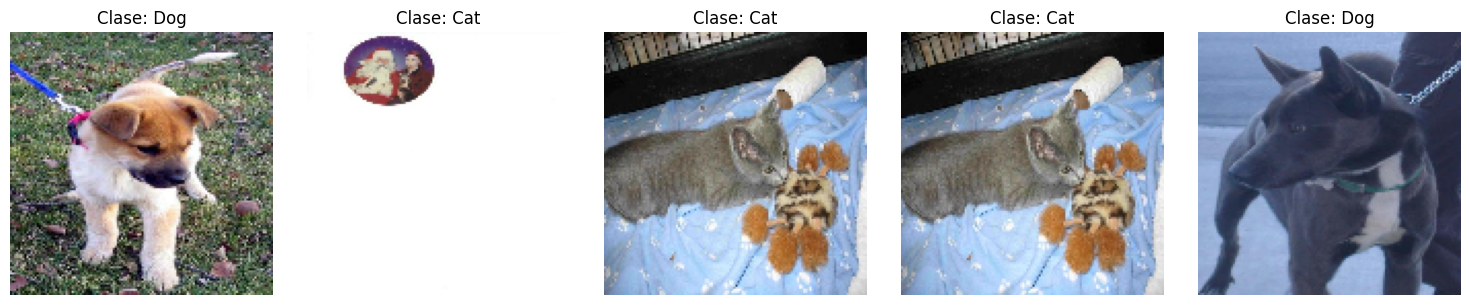

Ejemplos de imágenes de VALIDACIÓN:


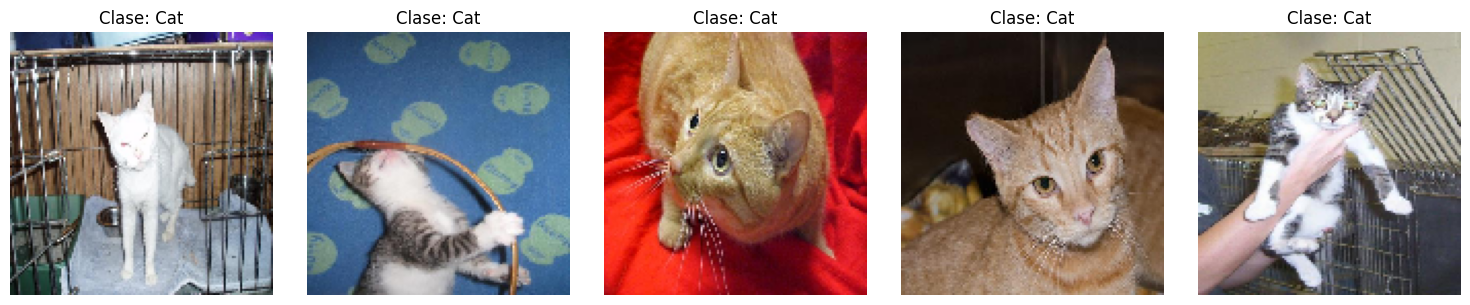

In [ ]:
def plot_sample_images(generator, num_samples=5):
    # Obtener un batch
    images, labels = next(generator)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        idx = np.random.randint(0, len(images))
        axes[i].imshow(images[idx])
        axes[i].set_title(f"Clase: {'Cat' if labels[idx] < 0.5 else 'Dog'}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

print("Ejemplos de imágenes de ENTRENAMIENTO:")
plot_sample_images(train_generator)

print("Ejemplos de imágenes de VALIDACIÓN:")
plot_sample_images(validation_generator)

# 6. Definir arquitectura CNN simple
    Red neuronal convolucional simple de 3 capas.
    Arquitectura:
    - Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Conv2D(128) -> MaxPool
    - Flatten -> Dense(128) -> Dropout(0.5) -> Dense(1) con sigmoid

In [ ]:
from tensorflow.keras import layers, models, optimizers

def create_simple_cnn(input_shape=(128, 128, 3)):

    model = models.Sequential([
        # Primera capa convolucional
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Segunda capa convolucional
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Tercera capa convolucional
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Capas densas
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Evita overfitting
        layers.Dense(1, activation='sigmoid')  # Clasificación binaria
    ])

    return model

# Creación de modelo
model = create_simple_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Compilar el modelo

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado correctamente")

Modelo compilado correctamente


# 8. Configurar callbacks (early stopping y checkpoints)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Carpeta para guardar modelos
os.makedirs('/content/models', exist_ok=True)

# Early stopping: para si no mejora después de 5 épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Guardar mejor modelo
checkpoint = ModelCheckpoint(
    '/content/models/best_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Reducir learning rate si no mejora
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stop, checkpoint, reduce_lr]

# 9. Entrenar la red

In [ ]:
import tensorflow.keras.backend as K
import gc

# 1. Limpiar sesión
K.clear_session()
gc.collect()

# 2. Compilar el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# 3. Definir callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

# 4. Entrenar
EPOCHS = 100

print("Comenzando entrenamiento...")
print("-" * 50)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("-" * 50)
print("Entrenamiento completado")

Comenzando entrenamiento...
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 442s 17s/step - accuracy: 0.5249 - loss: 0.7170 - precision: 0.5114 - recall: 0.5425 - val_accuracy: 0.5915 - val_loss: 0.6869 - val_precision: 0.5688 - val_recall: 0.3131 - learning_rate: 0.0010
Epoch 2/100
 1/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5469 - loss: 0.6898 - precision: 0.5294 - recall: 0.3000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 832ms/step - accuracy: 0.5469 - loss: 0.6898 - precision: 0.5294 - recall: 0.3000 - val_accuracy: 0.6027 - val_loss: 0.6861 - val_precision: 0.5625 - val_recall: 0.4545 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step - accuracy: 0.6068 - loss: 0.6662 - precision: 0.6024 - recall: 0.6343 - val_accuracy: 0.6250 - val_loss: 0.6476 - val_precision: 0.8125 - val_recall: 0.1970 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5625 - loss: 0.6519 - precision: 0.8571 - recall: 0.1818 - val_accuracy: 0.6384 - val_loss: 0.6411 - val_precision: 0.6731 - val_recall: 0.3535 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 352ms/step - accuracy: 0.6378 - loss: 0.6407 - precision: 0.6493 - recall: 0.5706 - val_accuracy: 0.7054 - val_loss: 0.6046 - val_precision: 0.6919 - val_recall: 0.6010 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7344 

# 10. Visualizar curvas de entrenamiento

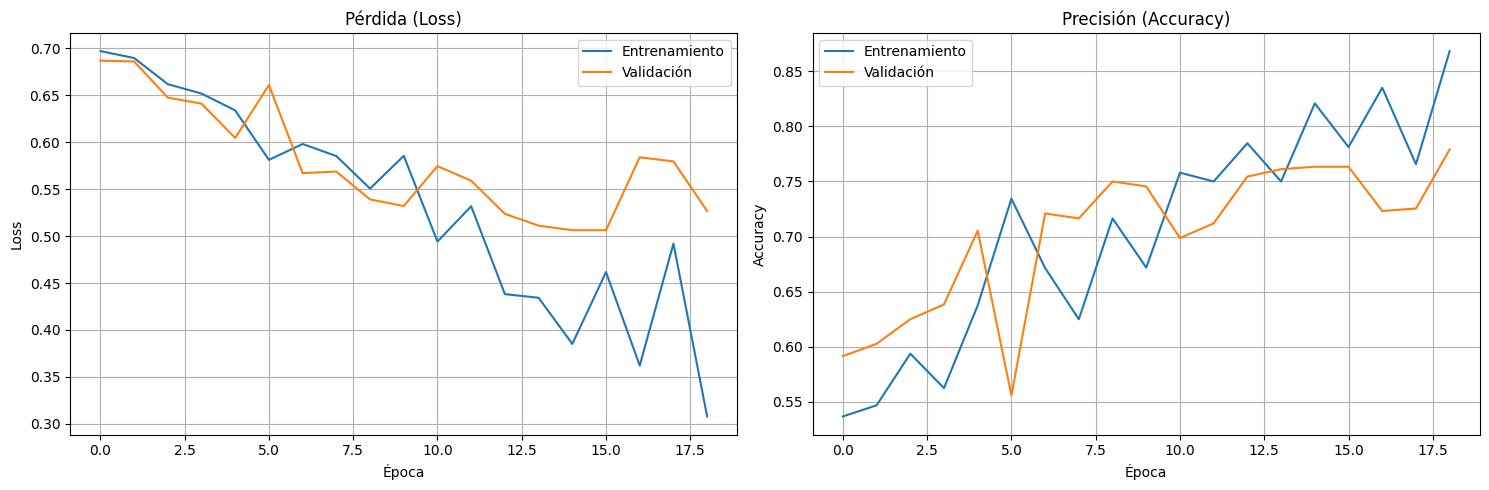


 Mejor accuracy en validación: 0.7790 (77.90%)


In [ ]:
def plot_training_history(history):
    """Dibuja las curvas de pérdida y precisión"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Pérdida
    ax1.plot(history.history['loss'], label='Entrenamiento')
    ax1.plot(history.history['val_loss'], label='Validación')
    ax1.set_title('Pérdida (Loss)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Precisión
    ax2.plot(history.history['accuracy'], label='Entrenamiento')
    ax2.plot(history.history['val_accuracy'], label='Validación')
    ax2.set_title('Precisión (Accuracy)')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Mejor accuracy de validación
    best_val_acc = max(history.history['val_accuracy'])
    print(f"\n Mejor accuracy en validación: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

plot_training_history(history)

# 11. Guardar modelo final en Drive

In [ ]:
# Guardar en Drive para no perderlo
drive_path = "/content/drive/MyDrive/PERROS_GATOS/models/"
os.makedirs(drive_path, exist_ok=True)

# Guardar el modelo completo
model.save(os.path.join(drive_path, 'mi_primera_cnn.h5'))
print(f"Modelo guardado en: {drive_path}")

# Guardar historial de entrenamiento
import pickle
with open(os.path.join(drive_path, 'history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)
print("Historial de entrenamiento guardado")

Modelo guardado en: /content/drive/MyDrive/PERROS_GATOS/models/
Historial de entrenamiento guardado
